# PROJECT

In [1]:
#importing all neccessary library:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#All availbale style of graphs.

plt.style.available 

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [3]:
#here using "ggplot" style. 

plt.style.use("ggplot") 

## PART-1 : Load Dataset

In [4]:
#reading csv file.

df = pd.read_csv(r"C:\Users\saurabh\Desktop\Python EDA project\EDA_Project_india_word_ecpnomic_sectors-DATA(CSV).csv") 

In [5]:
#display top 10 records.

df.head(10) 

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
0,France,2013,Agriculture,2286,45%,4.1
1,Germany,2013,Agriculture,1689,30%,NaN
2,UK,2011,Agriculture,469,55%,-2.5
3,France,2014,Manufacturing,1876,30%,NaN
4,China,2010,Manufacturing,3188,25%,4.1
5,Brazil,2018,Services,3739,45%,5.6
6,UK,2014,Services,256,40%,5.6
7,UK,2015,Services,3440,40%,7.8
8,France,2011,Manufacturing,3920,12%,NaN
9,USA,2019,Services,3846,30%,5.6


In [6]:
#display bottom 10 records.

df.tail(10) 

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
14990,Brazil,2018,Services,2216,45%,-2.5
14991,UK,2015,Agriculture,431,12%,0.0
14992,France,2010,Services,3642,40%,-2.5
14993,India,2022,Services,1483,40%,7.8
14994,UK,2019,Services,4194,25%,-2.5
14995,India,2011,Manufacturing,3931,NaN,0.0
14996,Germany,2016,Services,3491,40%,3.2
14997,UK,2019,Agriculture,3454,NaN,7.8
14998,Brazil,2016,Manufacturing,4294,25%,5.6
14999,France,2012,Services,2254,30%,3.2


In [21]:
#show the total numbers of rows and columns.

df.shape 

(15000, 6)

In [24]:
#total columns with name presented in dataset.

df.columns

Index(['Country ', 'Year', 'Sector ', 'GDP_Value_USD_Bn', 'Employment_%',
       'Growth_Rate_%'],
      dtype='object')

In [25]:
#Display the type of data present in each column.

df.dtypes 

Country              object
Year                  int64
Sector               object
GDP_Value_USD_Bn      int64
Employment_%         object
Growth_Rate_%       float64
dtype: object

In [13]:
#Information about data.

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           15000 non-null  object 
 1   Year              15000 non-null  int64  
 2   Sector            15000 non-null  object 
 3   GDP_Value_USD_Bn  15000 non-null  int64  
 4   Employment_%      13080 non-null  object 
 5   Growth_Rate_%     12836 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 703.3+ KB


In [27]:
#it show the sample of records randomly.

df.sample(5) 

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
7166,China,2017,Manufacturing,1757,25%,7.8
7676,Japan,2016,Agriculture,4370,12%,7.8
4255,Germany,2012,Agriculture,1277,35%,7.8
34,Japan,2012,Manufacturing,4156,12%,5.6
8623,UK,2015,Manufacturing,1508,30%,NaN


## PART-2 : Data Cleaning

In [17]:
#Total missing value present in dataset.

df.isnull().sum()

Country                0
Year                   0
Sector                 0
GDP_Value_USD_Bn       0
Employment_%        1920
Growth_Rate_%       2164
dtype: int64

In [28]:
#display the percentage of missing values present in each column.

(df.isnull().sum()/len(df))*100 

Country              0.000000
Year                 0.000000
Sector               0.000000
GDP_Value_USD_Bn     0.000000
Employment_%        12.800000
Growth_Rate_%       14.426667
dtype: float64

In [33]:
#Display the total duplicate records present in dataset.

df.duplicated().sum() #zero duplicate present in dataset.

np.int64(0)

In [35]:
#Droping all duplicate records if presented in dataset.

df.drop_duplicates(inplace = True) #inplace = True means permanent change in orignal dataset.

In [66]:
#Number of unique values present in each column of dataset.

df.nunique()

Country                8
Year                  14
Sector                 3
GDP_Value_USD_Bn    4686
Employment_%           8
Growth_Rate_%          7
dtype: int64

In [29]:
#Removing percentage value in numeric.

df["Employment_%"] = df["Employment_%"].str.replace("%","") #first we replace % using "" empty string.
df["Employment_%"] = pd.to_numeric(df["Employment_%"]) #then covert str to numeric.

In [30]:
#Checking the type after conversion.

df["Employment_%"].dtype 

dtype('float64')

In [31]:
#Converting into numeric data type.

df["Growth_Rate_%"] = pd.to_numeric(df["Growth_Rate_%"])

In [32]:
#Checking the type after conversion.

df["Growth_Rate_%"].dtype 

dtype('float64')

In [33]:
#checking data types again after conversion of all dtype.

df.dtypes

Country              object
Year                  int64
Sector               object
GDP_Value_USD_Bn      int64
Employment_%        float64
Growth_Rate_%       float64
dtype: object

In [34]:
#Filling all the missing records in growth_Rate_% with the mean of records in this column.

df["Growth_Rate_%"].fillna(df["Growth_Rate_%"].mean(), inplace = True) 

C:\Users\saurabh\AppData\Local\Temp\ipykernel_15464\2554631707.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Growth_Rate_%"].fillna(df["Growth_Rate_%"].mean(), inplace = True)


In [35]:
df["Employment_%"].fillna(df["Employment_%"].mean(), inplace = True) 

C:\Users\saurabh\AppData\Local\Temp\ipykernel_15464\3345911123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Employment_%"].fillna(df["Employment_%"].mean(), inplace = True)


In [36]:
#Checking missing values again. 

df["Growth_Rate_%"].isnull().sum()  

np.int64(0)

In [37]:
df["Employment_%"].isnull().sum()

np.int64(0)

## PART-3 : Statistical Analysis

In [38]:
#statistical description about data.

df.describe() 

,Year,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
count,15000.00000,15000.000000,15000.000000,15000.000000
mean,2016.46160,2529.340467,34.583792,3.005033
std,4.03161,1427.924847,12.221608,3.173167
min,2010.00000,50.000000,12.000000,-2.500000
25%,2013.00000,1309.000000,30.000000,0.000000
50%,2016.00000,2527.000000,34.583792,3.200000
75%,2020.00000,3759.000000,41.250000,5.600000
max,2023.00000,4999.000000,55.000000,7.800000


In [39]:
#display count of records in GDP column.

df["GDP_Value_USD_Bn"].count()

np.int64(15000)

In [40]:
#display mean of GDP column.

df["GDP_Value_USD_Bn"].mean()

np.float64(2529.3404666666665)

In [41]:
#display min record of GDP column.

df["GDP_Value_USD_Bn"].min()

50

In [42]:
#display max record of GDP column.

df["GDP_Value_USD_Bn"].max()

4999

In [80]:
#display standard deviation of GDP column.

df["GDP_Value_USD_Bn"].std()

1427.9248468927492

## Exploratory Data Analysis

In [34]:
df.sample(5)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
2431,Brazil,2013,Manufacturing,1893,35.0,3.2
4751,India,2022,Manufacturing,309,55.0,5.6
3597,China,2010,Agriculture,3332,12.0,-2.5
8130,Germany,2012,Services,884,25.0,7.8
14772,India,2014,Manufacturing,4467,45.0,5.6


In [43]:
#In country country there is a space. i.e : 'Country ' 

df.columns

Index(['Country', 'Year', 'Sector', 'GDP_Value_USD_Bn', 'Employment_%',
       'Growth_Rate_%'],
      dtype='object')

In [44]:
#Trim all extra space from the column name.

df.columns = df.columns.str.strip() 

In [45]:
#All extra spaces removed successfully.

df.columns 

Index(['Country', 'Year', 'Sector', 'GDP_Value_USD_Bn', 'Employment_%',
       'Growth_Rate_%'],
      dtype='object')

In [46]:
#Grouping total GDP by country.

df.groupby("Country")["GDP_Value_USD_Bn"].sum()

Country
Brazil     4580554
China      4552777
France     4737716
Germany    4794234
India      4916013
Japan      4766643
UK         4799501
USA        4792669
Name: GDP_Value_USD_Bn, dtype: int64

In [47]:
#Average GDP by Country.

df.groupby("Country")["GDP_Value_USD_Bn"].mean()

Country
Brazil     2503.034973
China      2491.941434
France     2521.402874
Germany    2559.655099
India      2567.108616
Japan      2555.840751
UK         2526.053158
USA        2507.937729
Name: GDP_Value_USD_Bn, dtype: float64

In [48]:
#Average Employment by Country.

df.groupby("Country")["Employment_%"].mean()

Country
Brazil     34.076613
China      35.044209
France     34.486755
Germany    34.417620
India      35.023559
Japan      34.540223
UK         34.447904
USA        34.624513
Name: Employment_%, dtype: float64

In [49]:
#Average Growth_Rate by Country.

df.groupby("Country")["Growth_Rate_%"].mean()

Country
Brazil     3.020143
China      2.916242
France     2.982754
Germany    3.010753
India      3.010686
Japan      2.952157
UK         3.116784
USA        3.026580
Name: Growth_Rate_%, dtype: float64

In [39]:
df.sample(5)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
5535,Brazil,2015,Manufacturing,3511,30.0,4.1
4439,Brazil,2019,Manufacturing,4614,40.0,3.2
4296,USA,2016,Services,2274,35.0,5.6
1399,UK,2015,Agriculture,1596,35.0,0.0
10108,Germany,2019,Agriculture,3751,40.0,3.2


In [121]:
#Total GDP by sector.

df.groupby("Sector")["GDP_Value_USD_Bn"].sum()

Sector
Agriculture      12772620
Manufacturing    12397550
Services         12769937
Name: GDP_Value_USD_Bn, dtype: int64

In [122]:
#Average Growth_Rate by Sector.

df.groupby("Sector")["Growth_Rate_%"].mean()

Sector
Agriculture      2.957249
Manufacturing    3.056838
Services         3.002594
Name: Growth_Rate_%, dtype: float64

In [123]:
#Average Employment by Sector

df.groupby("Sector")["Employment_%"].mean()

Sector
Agriculture      34.712761
Manufacturing    34.428102
Services         34.605204
Name: Employment_%, dtype: float64

In [128]:
#Total GDP by year

df.groupby("Year")["GDP_Value_USD_Bn"].sum()

Year
2010    2692476
2011    2826119
2012    2688674
2013    2670747
2014    2679632
2015    2761658
2016    2654246
2017    2811229
2018    2594641
2019    2810050
2020    2503463
2021    2675718
2022    2807778
2023    2763676
Name: GDP_Value_USD_Bn, dtype: int64

In [132]:
#Maximum GDP by year

df.groupby("Year")["GDP_Value_USD_Bn"].max()

Year
2010    4987
2011    4997
2012    4996
2013    4988
2014    4997
2015    4996
2016    4999
2017    4999
2018    4993
2019    4996
2020    4995
2021    4998
2022    4992
2023    4994
Name: GDP_Value_USD_Bn, dtype: int64

In [131]:
#Minimum GDP by year

df.groupby("Year")["GDP_Value_USD_Bn"].min()

Year
2010    50
2011    50
2012    53
2013    51
2014    53
2015    60
2016    50
2017    50
2018    59
2019    58
2020    51
2021    53
2022    50
2023    56
Name: GDP_Value_USD_Bn, dtype: int64

## PART-5 : Visualization

In [133]:
#Setting the size of figure.

plt.figure(figsize= (10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

### 1. Bar Chart

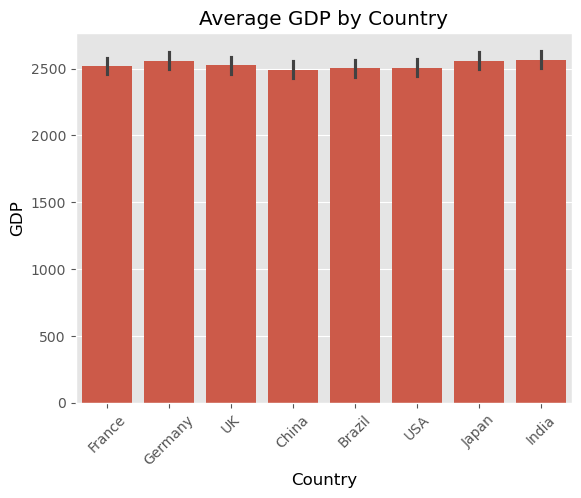

In [147]:
sns.barplot(df, x = "Country", y = "GDP_Value_USD_Bn", estimator = np.mean)
plt.title("Average GDP by Country")
plt.xlabel("Country", color = "black")
plt.ylabel("GDP", color = "black")
plt.xticks(rotation = 45) 

plt.show()

### 2. Pie Chart

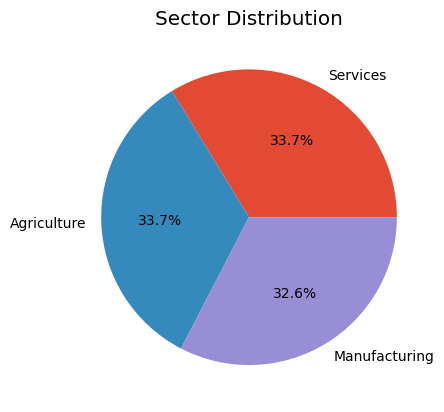

In [170]:
counts = df["Sector"].value_counts()
counts.plot(kind = "pie", autopct="%0.1f%%")
plt.title("Sector Distribution")
plt.ylabel("")

plt.show()

### 3. Histogram

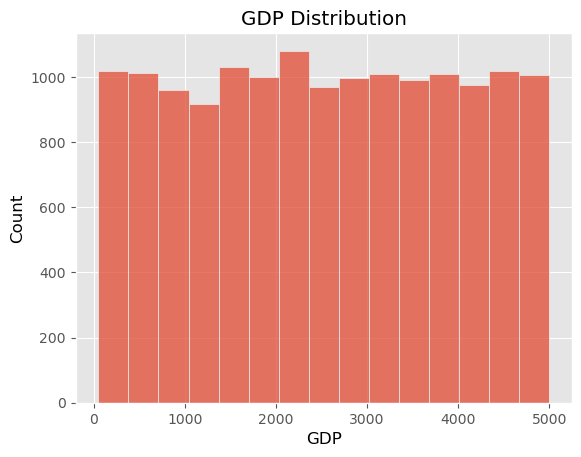

In [186]:
sns.histplot(df["GDP_Value_USD_Bn"], bins = 15)
plt.title("GDP Distribution")
plt.xlabel("GDP", color = "black")
plt.ylabel("Count", color = "black")

plt.show()

### 4. Histogram with KDE

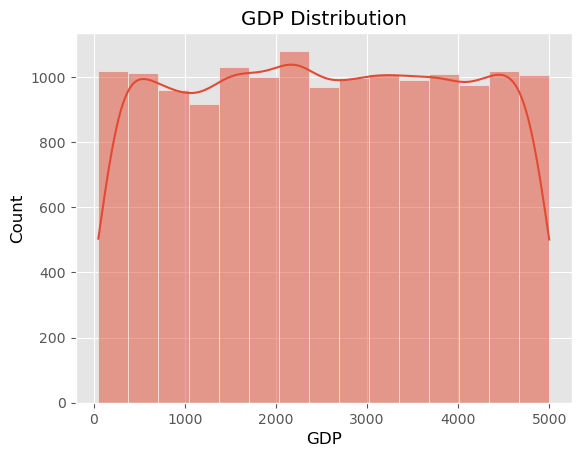

In [185]:
sns.histplot(df["GDP_Value_USD_Bn"], kde=True, bins = 15)
plt.title("GDP Distribution")
plt.xlabel("GDP", color = "black")
plt.ylabel("Count", color = "black")

plt.show()

### 5. Box Plot

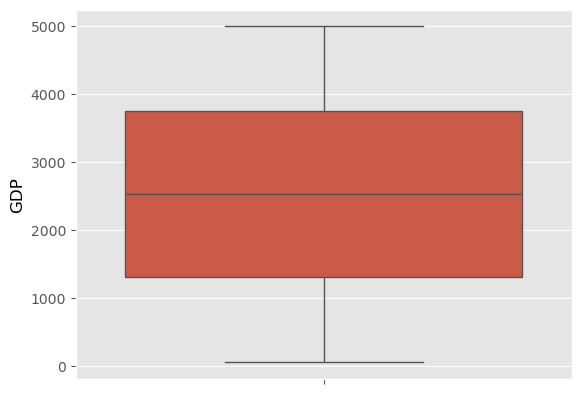

In [192]:
sns.boxplot(data = df["GDP_Value_USD_Bn"])
plt.ylabel("GDP", color = "black")

plt.show()

### 6. Scatter Plot

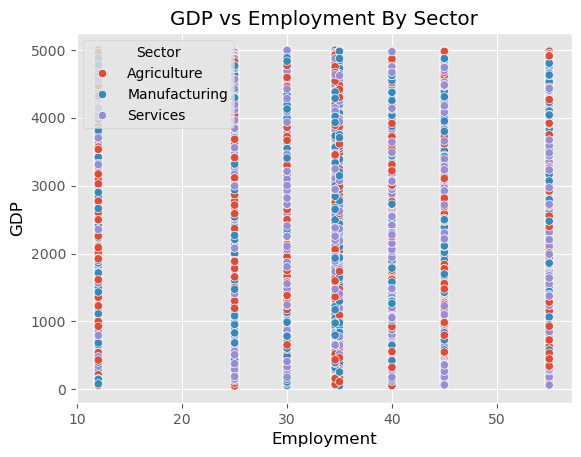

In [83]:
sns.scatterplot(data = df, x = "Employment_%", y = "GDP_Value_USD_Bn", hue="Sector")
plt.title("GDP vs Employment By Sector")
plt.xlabel("Employment", color = "black")
plt.ylabel("GDP", color = "black")

plt.show()

### 7. Line Plot

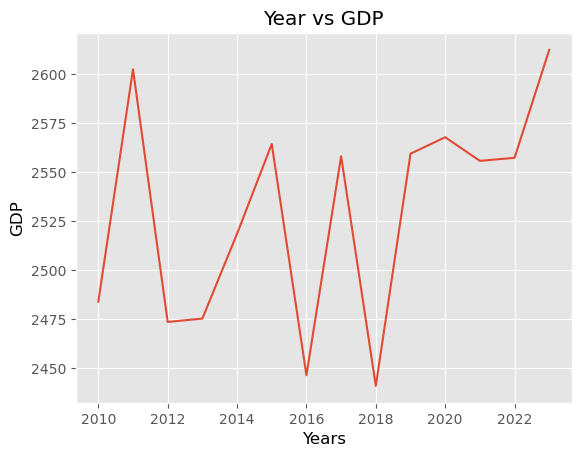

In [216]:
year=df.groupby("Year")["GDP_Value_USD_Bn"].mean()
year.plot(kind = "line")
plt.title("Year vs GDP")
plt.xlabel("Years", color = "black")
plt.ylabel("GDP", color = "black")

plt.show()

### 8. Count Plot

In [40]:
df.head()

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
0,France,2013,Agriculture,2286,45.0,4.100000
1,Germany,2013,Agriculture,1689,30.0,3.005033
2,UK,2011,Agriculture,469,55.0,-2.500000
3,France,2014,Manufacturing,1876,30.0,3.005033
4,China,2010,Manufacturing,3188,25.0,4.100000


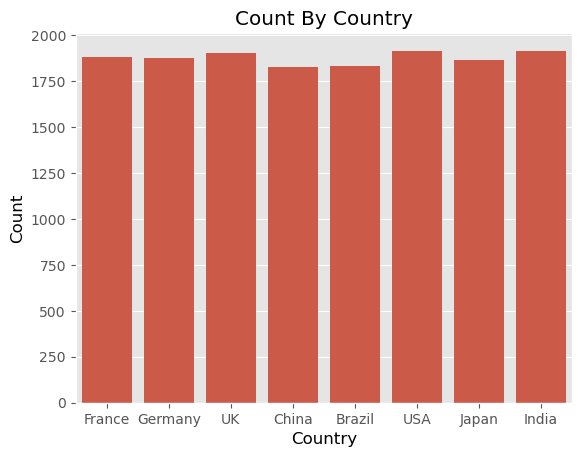

In [30]:
sns.countplot(data = df, x = "Country")
plt.title("Count By Country")
plt.xlabel("Country", color = "black")
plt.ylabel("Count", color = "black")

plt.show()

### 9. Heatmap

In [39]:
corr = df.select_dtypes(include = np.number).corr()
corr

,Year,GDP_Value_USD_Bn,Growth_Rate_%
Year,1.000000,0.015392,-0.011220
GDP_Value_USD_Bn,0.015392,1.000000,-0.004073
Growth_Rate_%,-0.011220,-0.004073,1.000000


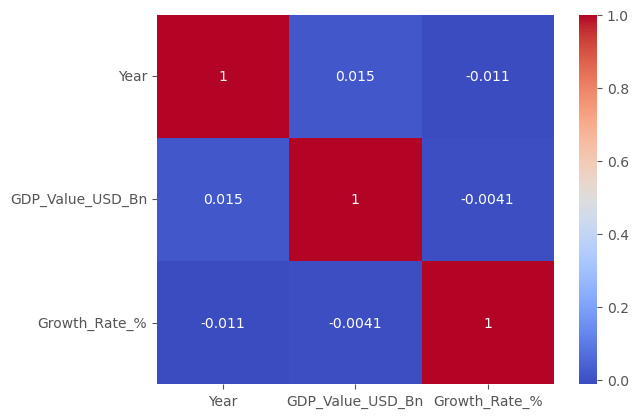

In [43]:
sns.heatmap(data = corr, annot=True, cmap="coolwarm")
plt.show()

### 10. Pair Plot

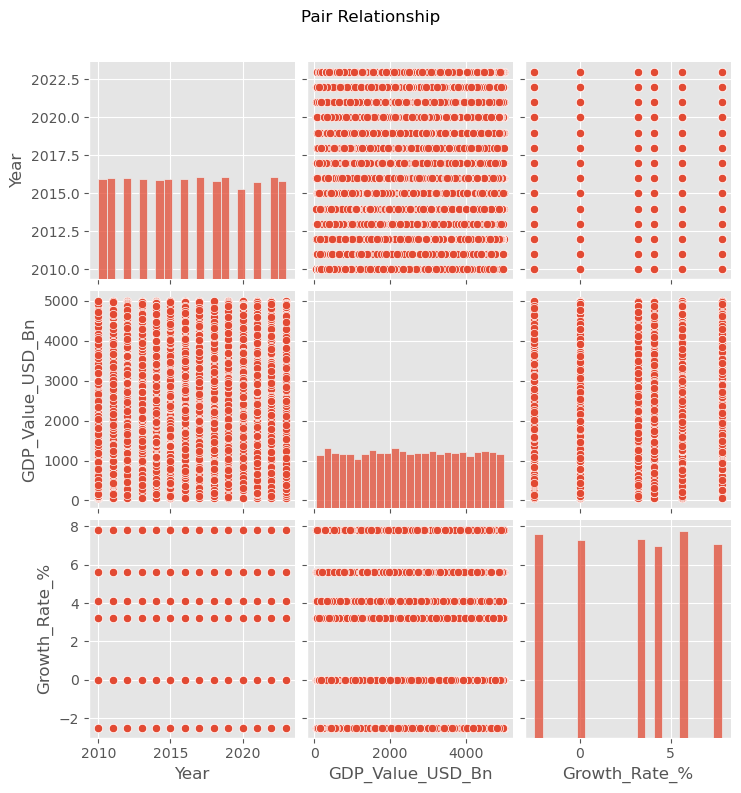

In [54]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle("Pair Relationship", x=0.5, y=1.05)
plt.show()

### 11. Violin Plot

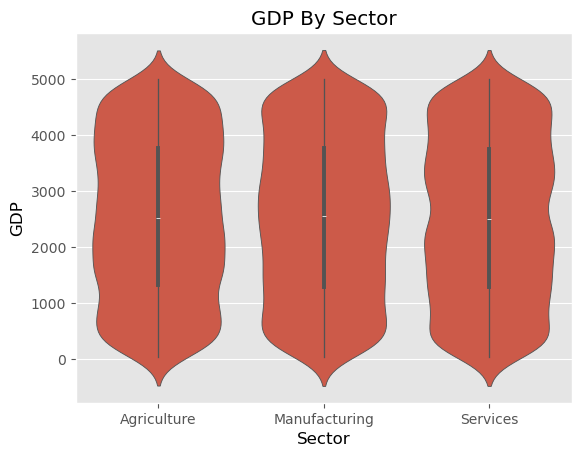

In [59]:
sns.violinplot(data=df, x="Sector", y="GDP_Value_USD_Bn")
plt.title("GDP By Sector")
plt.xlabel("Sector", color = "black")
plt.ylabel("GDP", color = "black")

plt.show()

## PART-6 : Advanced EDA

In [41]:
df.sample(5)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
9072,USA,2014,Manufacturing,1051,40.000000,0.000000
7225,Brazil,2021,Manufacturing,3895,55.000000,4.100000
7331,India,2022,Agriculture,3129,35.000000,3.005033
7664,Japan,2019,Manufacturing,1084,34.583792,7.800000
5141,France,2022,Manufacturing,790,12.000000,-2.500000


In [56]:
#Top 5 Countries by GDP

df.groupby("Country")["GDP_Value_USD_Bn"].sum().sort_values(ascending = False)


Country
India      4916013
UK         4799501
Germany    4794234
USA        4792669
Japan      4766643
France     4737716
Brazil     4580554
China      4552777
Name: GDP_Value_USD_Bn, dtype: int64

In [43]:
#Bottom 5 Countries

df.groupby("Country")["GDP_Value_USD_Bn"].sum().sort_values(ascending = False).tail()

Country
USA       4792669
Japan     4766643
France    4737716
Brazil    4580554
China     4552777
Name: GDP_Value_USD_Bn, dtype: int64

In [52]:
#Highest Growth Sector

df.groupby("Sector")["GDP_Value_USD_Bn"].sum().nlargest(1)

Sector
Agriculture    12772620
Name: GDP_Value_USD_Bn, dtype: int64

In [55]:
#Lowest Growth Sector

df.groupby("Sector")["GDP_Value_USD_Bn"].sum().nsmallest(1)  #show my the smallest sector in terms of GDP

Sector
Manufacturing    12397550
Name: GDP_Value_USD_Bn, dtype: int64

In [59]:
#Country having Maximum Employment

df.groupby("Country")["Employment_%"].sum().nlargest(1)

Country
India    67070.115596
Name: Employment_%, dtype: float64

In [62]:
#Country having Minimum Employment

df.groupby("Country")["Employment_%"].sum().nsmallest(1)

Country
Brazil    62360.202141
Name: Employment_%, dtype: float64

In [63]:
#GDP Trend over Years

df.groupby("Year")["GDP_Value_USD_Bn"].sum()

Year
2010    2692476
2011    2826119
2012    2688674
2013    2670747
2014    2679632
2015    2761658
2016    2654246
2017    2811229
2018    2594641
2019    2810050
2020    2503463
2021    2675718
2022    2807778
2023    2763676
Name: GDP_Value_USD_Bn, dtype: int64

In [64]:
#Sector with Maximum GDP

df.groupby("Sector")["GDP_Value_USD_Bn"].sum().nlargest(1)

Sector
Agriculture    12772620
Name: GDP_Value_USD_Bn, dtype: int64

In [92]:
#Average GDP per Sector

df.groupby("Sector")["GDP_Value_USD_Bn"].mean()

Sector
Agriculture      2529.231683
Manufacturing    2534.767941
Services         2524.201819
Name: GDP_Value_USD_Bn, dtype: float64

In [68]:
#Pivot Table

df.head(10)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
0,France,2013,Agriculture,2286,45.0,4.100000
1,Germany,2013,Agriculture,1689,30.0,3.005033
2,UK,2011,Agriculture,469,55.0,-2.500000
3,France,2014,Manufacturing,1876,30.0,3.005033
4,China,2010,Manufacturing,3188,25.0,4.100000
5,Brazil,2018,Services,3739,45.0,5.600000
6,UK,2014,Services,256,40.0,5.600000
7,UK,2015,Services,3440,40.0,7.800000
8,France,2011,Manufacturing,3920,12.0,3.005033
9,USA,2019,Services,3846,30.0,5.600000


In [69]:
#using pivot table analyzing sector wise total GDP:

df.pivot_table(values = "GDP_Value_USD_Bn", index = "Sector", aggfunc = "sum") 

,GDP_Value_USD_Bn
Sector,
Agriculture,12772620
Manufacturing,12397550
Services,12769937


In [74]:
#using pivot table analyzing sector wise average GDP:

df.pivot_table(values = "GDP_Value_USD_Bn", index = "Sector", aggfunc = "mean") 

,GDP_Value_USD_Bn
Sector,
Agriculture,2529.231683
Manufacturing,2534.767941
Services,2524.201819


In [100]:
#using pivot table analyzing country wise total GDP

df.pivot_table(values = "GDP_Value_USD_Bn", index = "Country", aggfunc = "sum") 

,GDP_Value_USD_Bn
Country,
Brazil,4580554
China,4552777
France,4737716
Germany,4794234
India,4916013
Japan,4766643
UK,4799501
USA,4792669


In [73]:
#using pivot table analyzing country wise avgerage GDP

df.pivot_table(index = "Country", values = "GDP_Value_USD_Bn", aggfunc = "mean")

,GDP_Value_USD_Bn
Country,
Brazil,2503.034973
China,2491.941434
France,2521.402874
Germany,2559.655099
India,2567.108616
Japan,2555.840751
UK,2526.053158
USA,2507.937729


In [54]:
#using pivot table analyzing year wise total Employement:

df.pivot_table(index = "Year", values = "Employment_%", aggfunc = "sum")

,Employment_%
Year,
2010,37669.320183
2011,37811.077064
2012,38082.476758
2013,37262.141590
2014,36440.563303
2015,37430.395719
2016,37470.725382
2017,38208.574312
2018,37080.817431


In [76]:
#using pivot table analyzing year wise avg Employement:

df.pivot_table(index = "Year", values = "Employment_%", aggfunc = "mean")

,Employment_%
Year,
2010,34.750295
2011,34.816830
2012,35.034477
2013,34.533959
2014,34.248650
2015,34.754314
2016,34.535231
2017,34.766674
2018,34.883177


In [78]:
#using pivot table analyzing Sector wise total Growth_Rate:

df.pivot_table(index = "Sector", values = "Growth_Rate_%", aggfunc = "sum")

,Growth_Rate_%
Sector,
Agriculture,14969.754409
Manufacturing,14913.903428
Services,15191.832970


In [81]:
#using pivot table analyzing Sector wise average Growth_Rate:

df.pivot_table(index = "Sector", values = "Growth_Rate_%", aggfunc = "mean")

,Growth_Rate_%
Sector,
Agriculture,2.964308
Manufacturing,3.049254
Services,3.002932


In [85]:
#using pivot table analyzing total Sector records by country :

df.pivot_table(index = "Country", values = "Sector", aggfunc = "count")

,Sector
Country,
Brazil,1830
China,1827
France,1879
Germany,1873
India,1915
Japan,1865
UK,1900
USA,1911


In [92]:
df.head(5)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
0,France,2013,Agriculture,2286,45.0,4.100000
1,Germany,2013,Agriculture,1689,30.0,3.005033
2,UK,2011,Agriculture,469,55.0,-2.500000
3,France,2014,Manufacturing,1876,30.0,3.005033
4,China,2010,Manufacturing,3188,25.0,4.100000


In [90]:
#Crosstab:
#It shows how many records of Country are present in each Sector.

pd.crosstab(df["Sector"], df["Country"])

Country,Brazil,China,France,Germany,India,Japan,UK,USA
Sector,,,,,,,,
Agriculture,580,630,628,608,644,622,657,681
Manufacturing,596,586,628,623,630,612,631,585
Services,654,611,623,642,641,631,612,645


In [11]:
#It shows how many records of Sectors are present in each Country.

pd.crosstab(df["Country"], df["Sector"])

Sector,Agriculture,Manufacturing,Services
Country,,,
Brazil,580,596,654
China,630,586,611
France,628,628,623
Germany,608,623,642
India,644,630,641
Japan,622,612,631
UK,657,631,612
USA,681,585,645


In [18]:
#Outlier Detection:

In [41]:
Q1 = df["GDP_Value_USD_Bn"].quantile(0.25) #1 Quartile
Q3 = df["GDP_Value_USD_Bn"].quantile(0.75) #3 Quartile

In [42]:
IQR = Q3 - Q1 #IQR --> Interquartile Range.

In [43]:
print(IQR)

2450.0


In [44]:
outliers = df[(df["GDP_Value_USD_Bn"] < (Q1 - 1.5 * IQR)) | (df["GDP_Value_USD_Bn"] > (Q3 + 1.5 * IQR))]

In [45]:
print(outliers)

Empty DataFrame
Columns: [Country, Year, Sector, GDP_Value_USD_Bn, Employment_%, Growth_Rate_%]
Index: []


In [46]:
#There is no outlier present in this dataset, like this we can check for all numeric columns.

In [ ]:
# Missing Value Analysis:

In [52]:
# Count missing values in each column

print(df.isnull().sum()) #there is no missing value present after replacing the missing values.

Country             0
Year                0
Sector              0
GDP_Value_USD_Bn    0
Employment_%        0
Growth_Rate_%       0
dtype: int64


## PART-7 : Business Insights

In [57]:
df.head(5)

,Country,Year,Sector,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
0,France,2013,Agriculture,2286,45.0,4.100000
1,Germany,2013,Agriculture,1689,30.0,3.005033
2,UK,2011,Agriculture,469,55.0,-2.500000
3,France,2014,Manufacturing,1876,30.0,3.005033
4,China,2010,Manufacturing,3188,25.0,4.100000


In [29]:
df.corr(numeric_only =  True)

,Year,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
Year,1.000000,0.015392,-0.011304,-0.010383
GDP_Value_USD_Bn,0.015392,1.000000,0.001257,-0.003770
Employment_%,-0.011304,0.001257,1.000000,0.004621
Growth_Rate_%,-0.010383,-0.003770,0.004621,1.000000


In [33]:
df.groupby(["Employment_%","Year"])["GDP_Value_USD_Bn"].sum()

Employment_%  Year
12.0          2010    315760
              2011    371177
              2012    320722
              2013    376367
              2014    378957
                       ...  
55.0          2019    323885
              2020    372804
              2021    371487
              2022    372454
              2023    332953
Name: GDP_Value_USD_Bn, Length: 112, dtype: int64

In [50]:
# 1. Which country contributes the highest total GDP?

df.groupby("Country")["GDP_Value_USD_Bn"].sum().idxmax()

'India'

In [51]:
# 2. Which sector has the highest average GDP?

df.groupby("Sector")["GDP_Value_USD_Bn"].mean().idxmax()

'Manufacturing'

In [52]:
# 3. Which sector employs the largest workforce?

df.groupby("Sector")["Employment_%"].mean().idxmax()

'Agriculture'

In [53]:
# 4. Is there any relationship between employment and GDP?

df["Employment_%"].corr(df["GDP_Value_USD_Bn"])

np.float64(0.0012574022683694427)

In [55]:
# 5. Which year recorded the highest GDP?

df.groupby("Year")["GDP_Value_USD_Bn"].sum().idxmax()

np.int64(2011)

In [56]:
# 5. Which year recorded the highest GDP?

df.groupby("Year")["GDP_Value_USD_Bn"].sum().idxmax()

np.int64(2011)

In [57]:
# 7. Which sector has the lowest growth?

df.groupby("Sector")["Growth_Rate_%"].mean().idxmin()

'Agriculture'

In [58]:
# 8. Are there any outliers in GDP?

Q1, Q3 = df["GDP_Value_USD_Bn"].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df["GDP_Value_USD_Bn"] < Q1-1.5*IQR) | (df["GDP_Value_USD_Bn"] > Q3+1.5*IQR)]
len(outliers)

0

In [59]:
# 9. Which variables are positively correlated?

df.select_dtypes(include=np.number).corr()

,Year,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
Year,1.000000,0.015392,-0.011304,-0.010383
GDP_Value_USD_Bn,0.015392,1.000000,0.001257,-0.003770
Employment_%,-0.011304,0.001257,1.000000,0.004621
Growth_Rate_%,-0.010383,-0.003770,0.004621,1.000000


In [60]:
# 10. Which variables are negatively correlated?

df.select_dtypes(include=np.number).corr()

,Year,GDP_Value_USD_Bn,Employment_%,Growth_Rate_%
Year,1.000000,0.015392,-0.011304,-0.010383
GDP_Value_USD_Bn,0.015392,1.000000,0.001257,-0.003770
Employment_%,-0.011304,0.001257,1.000000,0.004621
Growth_Rate_%,-0.010383,-0.003770,0.004621,1.000000


In [61]:
# 11. Does higher employment always correspond to higher GDP?

df.groupby("Country")[["Employment_%","GDP_Value_USD_Bn"]].mean().sort_values("Employment_%", ascending=False)

,Employment_%,GDP_Value_USD_Bn
Country,,
China,35.044209,2491.941434
India,35.023559,2567.108616
USA,34.624513,2507.937729
Japan,34.540223,2555.840751
France,34.486755,2521.402874
UK,34.447904,2526.053158
Germany,34.417620,2559.655099
Brazil,34.076613,2503.034973


In [62]:
# 12. Which country has the most balanced sector performance?

pivot = df.pivot_table(values="GDP_Value_USD_Bn", index="Country", columns="Sector", aggfunc="sum")
pivot.std(axis=1).sort_values()

Country
Japan       14129.074740
India       17998.351369
Germany     32812.146516
France      39754.130104
China       60297.970159
UK          71650.054448
Brazil     100082.939117
USA        138555.140938
dtype: float64

In [63]:
# 13. Which sectors dominate across different countries?

pivot.idxmax(axis=1)

Country
Brazil          Services
China        Agriculture
France     Manufacturing
Germany         Services
India           Services
Japan        Agriculture
UK           Agriculture
USA          Agriculture
dtype: object

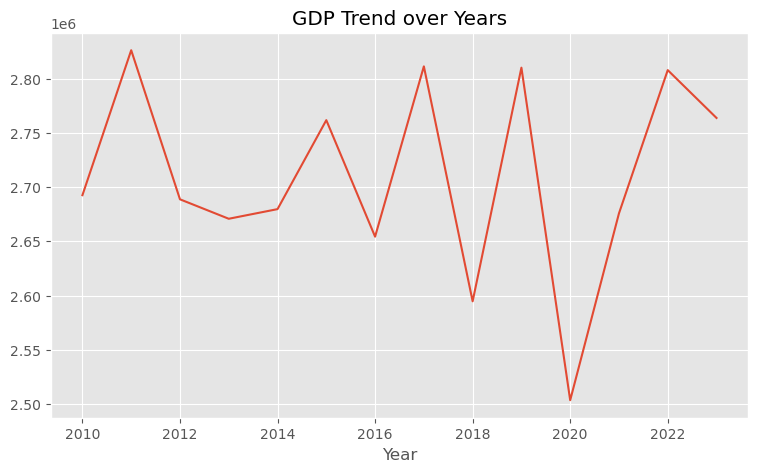

In [64]:
# 14. How does GDP vary over time?

gdp_trend = df.groupby("Year")["GDP_Value_USD_Bn"].sum()
gdp_trend.plot(kind="line", figsize=(9,5), title="GDP Trend over Years")
plt.show()

In [65]:
# 15. What data quality issues were found and how were they resolved?

df.isnull().sum()        
df.columns               
df["Employment_%"].unique() 

array([45.        , 30.        , 55.        , 25.        , 40.        ,
       12.        , 35.        , 34.58379205])